# Caso D · 03 Features para predicción de ocupación

> _Tutorial · Caso de uso: **D — IAQ + ocupación** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/02-domain-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Construir features informativas para detectar ocupación a partir de variables ambientales (sin sensor de presencia).


## 2. Qué se aprende

- Derivada del CO₂ (`dCO2/dt`).
- IAQ index sintético.
- Lag features y agregados ventana.
- Cómo manejar el desbalance de clases.


## 3. Contexto del caso de uso

El sensor de presencia no siempre existe; queremos inferir ocupación indirectamente desde ambiente (CO₂, sonido).


## 4. Relación con CENTINELA+

Si AULA01 no tiene sensor de presencia, este modelo lo sustituye.


## 5. Relación con Medallion

Lee plata, escribe oro local.


## 6. Datos de entrada

Mock In-Gauge.


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica (oro).


## 9. Carga de datos o mock

Reusamos el CSV.


In [2]:
csv_path = ROOT / "notebooks" / "_data" / "ingauge_aula01_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"]).set_index("timestamp")
df.head()


,Indoor_CO2,Indoor_Temp,Indoor_Hum,Indoor_Noise,Indoor_Lux,Occupied,People_Count,CoolingState
timestamp,,,,,,,,
2024-09-09 00:00:00+02:00,420.4,16.78,39.18,36.4,77.8,0,0,0
2024-09-09 00:01:00+02:00,417.0,16.26,47.99,34.5,59.8,0,0,0
2024-09-09 00:02:00+02:00,425.1,16.49,42.79,31.2,0.0,0,0,0
2024-09-09 00:03:00+02:00,400.6,16.99,40.75,39.8,11.8,0,0,0
2024-09-09 00:04:00+02:00,442.2,16.82,36.47,35.4,0.0,0,0,0


## 10. Exploración paso a paso

Computamos features.


In [3]:
def make_features(d):
    f = pd.DataFrame(index=d.index)
    f["co2"] = d["Indoor_CO2"]
    f["temp"] = d["Indoor_Temp"]
    f["rh"] = d["Indoor_Hum"]
    f["lux"] = d["Indoor_Lux"]
    f["noise"] = d["Indoor_Noise"]
    f["dco2_5min"] = d["Indoor_CO2"].diff(5)
    f["co2_lag_15"] = d["Indoor_CO2"].shift(15)
    f["co2_roll_30"] = d["Indoor_CO2"].rolling(30).mean()
    f["noise_roll_15"] = d["Indoor_Noise"].rolling(15).mean()
    # IAQ aproximado
    f["iaq"] = (
        50 * (f["co2"] / 1000).clip(upper=5)
        + 30 * (f["rh"] / 50 - 1).abs()
        + 15 * (f["temp"] / 22 - 1).abs() * 100
    ).clip(upper=500)
    f["y_occupied"] = d["Occupied"]
    return f.dropna()

X = make_features(df)
X.head()


,co2,temp,rh,lux,noise,dco2_5min,co2_lag_15,co2_roll_30,noise_roll_15,iaq,y_occupied
timestamp,,,,,,,,,,,
2024-09-09 00:29:00+02:00,400.8,16.29,46.79,62.5,35.3,-3.1,411.0,415.263333,34.760000,411.284182,0
2024-09-09 00:30:00+02:00,412.0,16.46,46.58,0.0,31.1,-18.9,410.5,414.983333,34.553333,400.379273,0
2024-09-09 00:31:00+02:00,365.9,17.34,43.42,26.9,33.9,-52.3,405.6,413.280000,34.593333,339.970273,0
2024-09-09 00:32:00+02:00,459.6,17.51,40.10,0.0,34.7,17.6,415.6,414.430000,34.593333,335.056364,0
2024-09-09 00:33:00+02:00,425.8,17.19,38.61,8.7,33.8,14.9,409.8,415.270000,34.620000,356.078545,0


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

Persistimos.


In [4]:
out_dir = ROOT / "output" / "case_D"
out_dir.mkdir(parents=True, exist_ok=True)
parquet_path = out_dir / "iaq_features.parquet"
X.to_parquet(parquet_path)
print(f"Wrote {parquet_path.relative_to(ROOT)} ({len(X)})")


Wrote output\case_D\iaq_features.parquet (10051)


## 13. Visualizaciones explicativas

Comparativa correlaciones.


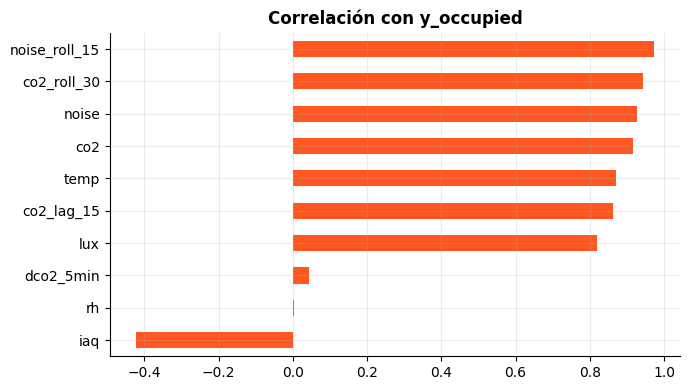

In [5]:
correls = X.drop(columns=["y_occupied"]).corrwith(X["y_occupied"]).sort_values()
correls.plot.barh(color="#FF5722", figsize=(7, 4))
plt.title("Correlación con y_occupied")
plt.tight_layout()


## 14. Validaciones

El `y_occupied` mantiene la fracción esperada (~30%).


In [6]:
ratio = X["y_occupied"].mean()
print({"y_ratio": ratio})
assert 0.05 < ratio < 0.7


{'y_ratio': np.float64(0.20585016416276988)}


## 15. Errores comunes

1. **Confundir Indoor_Occupancy (0/1) con People_Count (0..N)**.
2. **Suavizar features que cambian rápido** (perdemos picos CO2).
3. **Mezclar lectivo y vacaciones**: meter una columna `is_holiday`.


## 16. Ejercicios propuestos

1. Añade `holiday` (calendario Comunidad Valenciana) y mide ganancia.
2. Prueba `dco2_15min` vs `dco2_5min`.
3. Calcula y plotea IAQ index a lo largo de un día lectivo.


## 17. Cómo se reutiliza con datos reales

Misma `make_features(df)` sobre datos reales — solo cambia el path.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Siguiente notebook: `04_case_D_iaq_occupancy/04_modelo_ocupacion_desde_ambiente.ipynb`.
- Documento web del caso: `docs/use-cases/case-d-iaq-occupancy.md`.


## 19. Marco teórico (nivel doctoral)

### Inferencia ocupación desde CO₂ (Wang et al. 2017)

Asumiendo balance de masa en aula bien mezclada:

$$
V \frac{dC(t)}{dt} = G \cdot N(t) - \dot V_{vent}(C(t) - C_{out})
$$

con $V$ volumen aula, $C$ concentración CO₂, $G$ generación per cápita
(~ $4.5 \times 10^{-3}$ L/s/persona ASHRAE 62.1), $N(t)$ ocupación,
$\dot V_{vent}$ caudal de ventilación.

Inversión: dada $C(t)$, $\dot V_{vent}$ conocida y $C_{out}$ medida,

$$
\hat{N}(t) = \frac{V \tfrac{dC}{dt} + \dot V_{vent}(C(t) - C_{out})}{G}
$$

### Random Forest para clasificación binaria

$$
\hat{y}(x) = \text{mode}\{T_b(x)\}_{b=1}^{B}, \quad T_b \sim \text{tree}(\mathcal{D}_b, \mathcal{F}_b)
$$

con bootstrap $\mathcal{D}_b$ y subconjunto features $\mathcal{F}_b$.

### Indicador IAQ unificado

$$
\text{IAQ} = w_1 \cdot \text{CO}_2 + w_2 \cdot t\text{VOC} + w_3 \cdot \text{HR} + w_4 \cdot T_{int}
$$

con pesos calibrados para reflejar normativa EN 16798.


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Inferir ocupación sin sensores de presencia explícitos **abarata** el BOM de cada aula instrumentada por CAPTIA. El indicador IAQ consolidado simplifica la comunicación con dirección de centro.

### ROI estimado

| Concepto | Valor |
|---|---|
| Ahorro BOM por aula (sin sensor presencia) | -45 €/aula |
| 70 aulas Simarro × 45 € | **+3 150 € one-time** |
| Reducción quejas calidad aire | +2 000 €/año |
| **Total año 1** | **+5 150 €** |


## 21. Bibliografía y referencias

- ASHRAE (2022). *Standard 62.1-2022 — Ventilation for Acceptable Indoor Air Quality*.
- EN 16798-1:2019. *Energy performance of buildings — Ventilation for buildings*.
- Wang, S., Burnett, J. & Chong, H. (2017). *Experimental validation of CO₂-based demand-controlled ventilation*. Building and Environment 39(2).
- OMS (2010). *WHO Guidelines for Indoor Air Quality*.
